<a href="https://colab.research.google.com/github/chaimoma/SmartOutfitsAi/blob/main/ml/YoLoTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

In [ ]:
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"chaimazbairi","key":"KGAT_3a18172c905fcee2e3eda0d98c82cb1c"}')

In [ ]:
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("done")

done


In [ ]:
!kaggle datasets download -d chaimazbairi/SmartOutfitsSubset
print("download done")

Dataset URL: https://www.kaggle.com/datasets/chaimazbairi/SmartOutfitsSubset
License(s): unknown
100% 2.43G/2.44G [00:42<00:00, 250MB/s]
100% 2.44G/2.44G [00:42<00:00, 61.3MB/s]
download done


In [ ]:
!unzip -q SmartOutfitsSubset.zip -d /content/
print("done")

done


In [ ]:
import os
print("Train:", len(os.listdir('/content/subset/train/images')))
print("Val:", len(os.listdir('/content/subset/validation/images')))

Train: 40000
Val: 8000


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00


In [ ]:
import yaml

dataset = {
    'path': '/content/subset',
    'train': 'train/images',
    'val': 'validation/images',
    'nc': 13,
    'names': [
        'short sleeve top', 'long sleeve top',
        'short sleeve outwear', 'long sleeve outwear',
        'vest', 'sling', 'shorts', 'trousers', 'skirt',
        'short sleeve dress', 'long sleeve dress',
        'vest dress', 'sling dress'
    ]
}

with open('/content/subset/dataset.yaml', 'w') as f:
    yaml.dump(dataset, f)

print("yaml created")

yaml created


In [10]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/subset/dataset.yaml',
    imgsz=640,
    batch=16,
    epochs=10,
    name='smart_outfits',
    device=0
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/subset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smart_outfits2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7897d46fa360>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [11]:
from google.colab import files
files.download('/content/runs/detect/smart_outfits2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/8000 /content/subset/validation/images/000007.jpg: 640x480 1 sling dress, 40.4ms


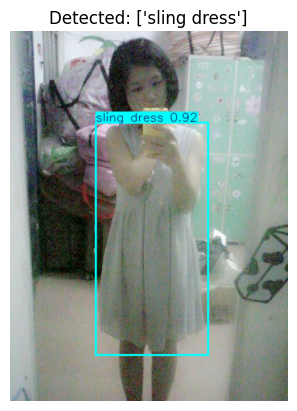

image 2/8000 /content/subset/validation/images/000008.jpg: 640x384 1 sling, 1 sling dress, 51.6ms


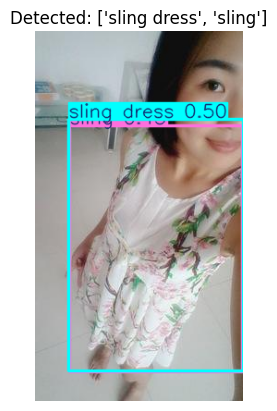

image 3/8000 /content/subset/validation/images/000012.jpg: 640x384 1 long sleeve dress, 8.2ms


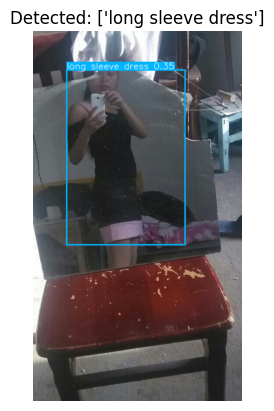

image 4/8000 /content/subset/validation/images/000014.jpg: 640x384 1 long sleeve top, 8.1ms


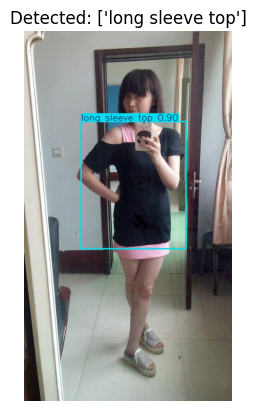

image 5/8000 /content/subset/validation/images/000028.jpg: 480x640 1 short sleeve dress, 45.2ms


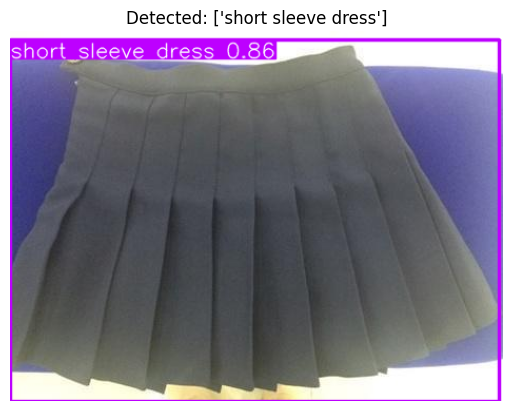

In [14]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO('/content/runs/detect/smart_outfits2/weights/best.pt')

results = model.predict(source='/content/subset/validation/images',
                        conf=0.25,
                        save=True,
                        max_det=10,
                        stream=True)

for i, r in enumerate(results):
    im = r.plot()
    plt.imshow(im[:, :, ::-1])
    plt.axis('off')
    plt.title(f"Detected: {[r.names[c] for c in r.boxes.cls.int().tolist()]}")
    plt.show()
    if i == 4:
        break